# DTGS182. Figure 1b: Single-Molecule Localization Microscopy (SMLM)

This notebook simulates a single-molecule localization microscopy (SMLM) image with DeepTrack2, reproducing the SMLM panel of Figure 1b. It generates two matching panels: the simulated composite image, and the ground-truth positions used to generate it.


In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.


In [2]:
import random

import numpy as np
from matplotlib import pyplot as plt

import deeptrack as dt


def seed_everything(seed: int = 123) -> None:
    random.seed(seed)
    np.random.seed(seed)


SEED = 123
seed_everything(SEED)

TILE_SIZE = 128
RESOLUTION = 1e-7  # 100 nm/px, Nyquist-sampled for NA=1.4 at this wavelength.


/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 1. Simulating the SMLM Image

A dense population of point emitters (`dt.PointParticle`) is imaged through a fluorescence microscope, then corrupted with a constant background offset and Poisson shot noise to mimic a single SMLM frame with overlapping emitters.


In [3]:
particle = dt.PointParticle(
    position=lambda: np.random.uniform(5, TILE_SIZE - 5, size=2),
    intensity=lambda: np.random.uniform(200, 1000),
    z=lambda: np.random.uniform(-0.1, 0.1) * dt.units.um,
)

optics = dt.Fluorescence(
    wavelength=640 * dt.units.nm,
    NA=1.4,
    magnification=1,
    resolution=RESOLUTION,
    output_region=(0, 0, TILE_SIZE, TILE_SIZE),
)

postprocess = dt.Add(lambda: np.random.uniform(10, 15)) >> dt.Poisson(SNR=50.0)

particles = particle ^ (lambda: np.random.randint(40, 60))
pipeline = optics(particles) >> postprocess


In [4]:
pipeline.update()
image = pipeline.resolve()

ground_truth_positions = dt.TakeProperties(particles, "position")
ground_truth_positions = np.array(ground_truth_positions())


## 2. Plotting the Composite Image

The simulated image is shown with a physical scale bar, computed from the pixel resolution set above.


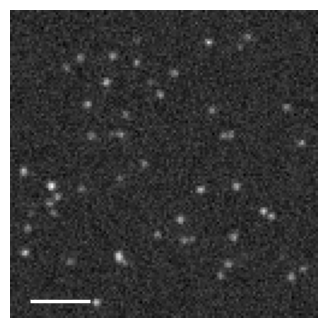

In [5]:
PIXELS_PER_UM = 1.0 / (RESOLUTION * 1e6)
SCALE_BAR_UM = 2.5
scale_bar_px = SCALE_BAR_UM * PIXELS_PER_UM

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(image, cmap="gray")
x0, y0 = TILE_SIZE * 0.06, TILE_SIZE * 0.94
ax.plot([x0, x0 + scale_bar_px], [y0, y0], color="white", linewidth=2.5,
        solid_capstyle="butt")
ax.axis("off")

fig.savefig("fig1b_smlm_sim.svg", format="svg", bbox_inches="tight",
            pad_inches=0, transparent=True)


## 3. Plotting the Ground Truth

The same emitter positions used to generate the image above, overlaid on a blank background as the ground-truth annotation.


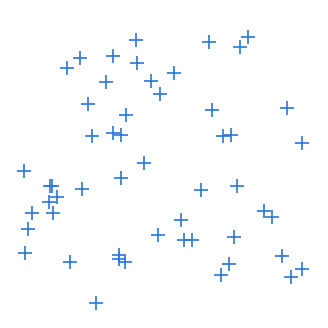

In [6]:
ground_truth_background = np.ones(image.shape, dtype=np.float32)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(ground_truth_background, cmap="gray", vmin=0, vmax=1)
ax.scatter(
    ground_truth_positions[:, 1], ground_truth_positions[:, 0],
    s=100, facecolors="#2a78d6", linewidths=1.2, marker="+", label="ground truth",
)
ax.axis("off")

fig.savefig("fig1b_smlm_gt.svg", format="svg", bbox_inches="tight",
            pad_inches=0, transparent=True)
